In [13]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
df = pd.read_csv('income1.csv')
df.head()

,Name,Age,Income
0,Alice,22,18000
1,Brian,25,35000
2,Cathy,19,15000
3,Derek,28,38000
4,Eva,21,22000


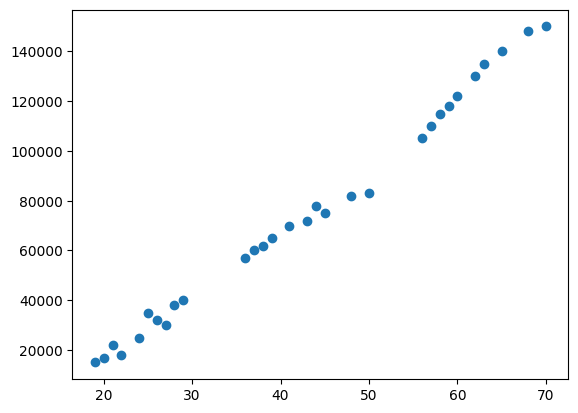

In [15]:
plt.scatter(df['Age'],df['Income'])

In [16]:
km = KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [17]:
Y_predicted = km.fit_predict(df[['Age','Income']])
Y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [18]:
df['cluster'] = Y_predicted
df.head()

,Name,Age,Income,cluster
0,Alice,22,18000,0
1,Brian,25,35000,0
2,Cathy,19,15000,0
3,Derek,28,38000,0
4,Eva,21,22000,0


C:\Users\avraj\AppData\Local\Temp\ipykernel_34092\3948505293.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


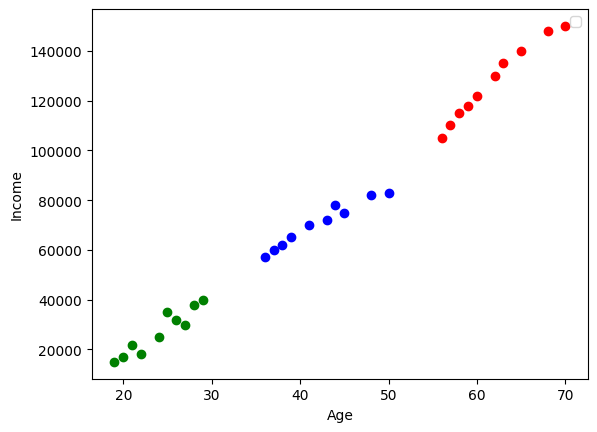

In [19]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1.Age,df1['Income'],color = 'green')
plt.scatter(df2.Age,df2['Income'],color = 'red')
plt.scatter(df3.Age,df3['Income'],color = 'blue')

plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

In [24]:
scaler = MinMaxScaler()
scaler.fit(df[['Income']])
df['Income'] = scaler.transform(df[['Income']])  # double brackets here

# ✅ Fixed
scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])
df

,Name,Age,Income,cluster
0,Alice,0.058824,0.022222,0
1,Brian,0.117647,0.148148,0
2,Cathy,0.000000,0.000000,0
3,Derek,0.176471,0.170370,0
4,Eva,0.039216,0.051852,0
5,Felix,0.156863,0.111111,0
6,Gina,0.098039,0.074074,0
7,Hank,0.196078,0.185185,0
8,Isla,0.019608,0.014815,0
9,Jake,0.137255,0.125926,0


In [25]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Income']])
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [29]:
df['cluster'] = y_predicted
df

,Name,Age,Income,cluster
0,Alice,0.058824,0.022222,1
1,Brian,0.117647,0.148148,1
2,Cathy,0.000000,0.000000,1
3,Derek,0.176471,0.170370,1
4,Eva,0.039216,0.051852,1
5,Felix,0.156863,0.111111,1
6,Gina,0.098039,0.074074,1
7,Hank,0.196078,0.185185,1
8,Isla,0.019608,0.014815,1
9,Jake,0.137255,0.125926,1


In [31]:
km.cluster_centers_

array([[0.45294118, 0.41037037],
       [0.1       , 0.09037037],
       [0.83921569, 0.83185185]])

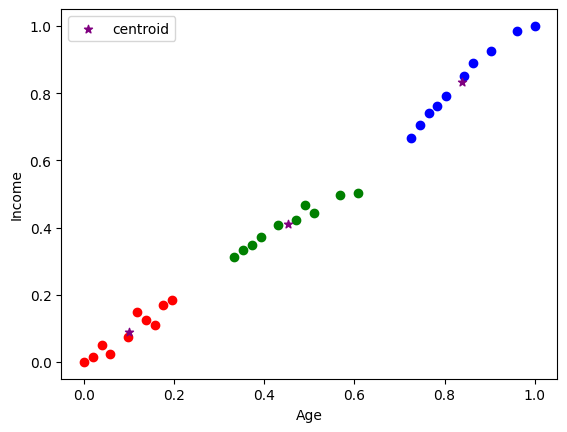

In [33]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1.Age,df1['Income'],color = 'green')
plt.scatter(df2.Age,df2['Income'],color = 'red')
plt.scatter(df3.Age,df3['Income'],color = 'blue')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color = 'purple',marker = '*',label = 'centroid')

plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

In [38]:
# Elbow method
k_rng = range(1, 10)  # k from 1 to 9

sse = []
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age', 'Income']])
    sse.append(km.inertia_)



In [39]:
sse

[5.901145213221251,
 1.469849983835488,
 0.4009561184919381,
 0.2512769700795674,
 0.1855605362293388,
 0.09900308365095412,
 0.06477318790019032,
 0.047373390734491164,
 0.04149948025688126]

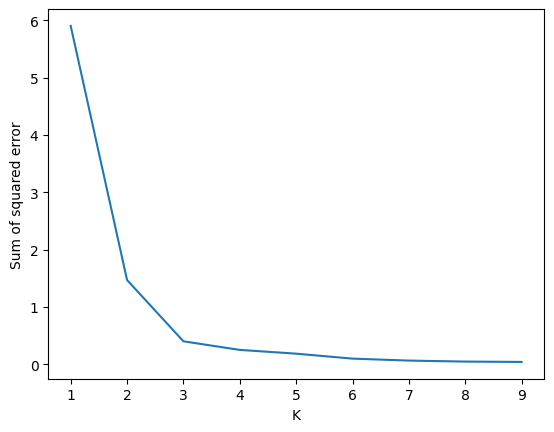

In [40]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)